# EDA Graphs — REHAB `Rehab_exercise`

Generates every figure referenced in [`EDA.md`](./EDA.md), saved to `EDA_Report/figures/`.
This notebook is self-contained (only needs `numpy`, `pandas`, `matplotlib`, `scipy`) and
finds the dataset automatically regardless of where Jupyter's working directory is, the
same way `Activity1.ipynb` and `ETL_Cleaning/ETL_Cleaning.ipynb` do.

Data source: `Data/Rehab_exercise/d02_processed_data/` (same files `EDA.md` and
`Activity1.ipynb` analyze), plus `d01_raw_data/` for the two "raw defect" figures
(invalid-angle example and padding artifact), since those defects are clearest before any
filtering is applied.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def find_rehab_dir(start=None):
    # Sube por los directorios padre a partir de `start` (por defecto, el
    # directorio de trabajo actual) hasta encontrar Data/Rehab_exercise.
    path = os.path.abspath(start or os.getcwd())
    while True:
        target = os.path.join(path, "Data", "Rehab_exercise")
        if os.path.isdir(target):
            return target
        parent = os.path.dirname(path)
        if parent == path:
            raise FileNotFoundError(f"No se encontró Data/Rehab_exercise subiendo desde {os.getcwd()}")
        path = parent

REHAB_DIR = find_rehab_dir()
RAW_DIR = os.path.join(REHAB_DIR, "d01_raw_data")
PROCESSED_DIR = os.path.join(REHAB_DIR, "d02_processed_data")
FIG_DIR = os.path.join(os.path.abspath("."), "figures")
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"

MOVEMENT_NAMES = {
    0: "Bobath handshake", 1: "Bobath flexion/extension",
    2: "Bobath forward flexion/extension", 3: "Bobath ant/post rotation",
    4: "Elbow flexion + wrist compression", 5: "Wrist flexion/extension",
    6: "Finger-to-finger training", 7: "Ball gripping",
    8: "Shoulder internal/external rotation", 9: "Breast expansion",
    10: "Flexion-pressure rotation fwd/back", 11: "Elbow flexion and touch",
    12: "Shoulder touch training", 13: "Ankle ext. & knee int/ext rotation",
    14: "Knee flexion/extension", 15: "Hip flexion/extension",
}
LIMB = {i: ("upper" if i <= 12 else "lower") for i in range(16)}
CHANNELS_SENSOR1 = ["pitch1", "yaw1", "roll1", "pitch2", "yaw2", "roll2"]
CHANNELS_SENSOR2 = ["f1_thumb", "f2_index", "f3_middle", "f4_ring", "f5_little", "pitch3_wrist"]
UPPER_COLOR, LOWER_COLOR = "#1f77b4", "#d62728"

print("Rehab_exercise:", REHAB_DIR)
print("Figures will be saved to:", FIG_DIR)

Rehab_exercise: /Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/Data/Rehab_exercise
Figures will be saved to: /Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/EDA_Report/figures


## Figure 1 — Class balance (repetition count per movement)

Supports EDA.md Step 1 / Step 3 issue #5 (class imbalance, 1.82x ratio between
the least- and most-represented movement).

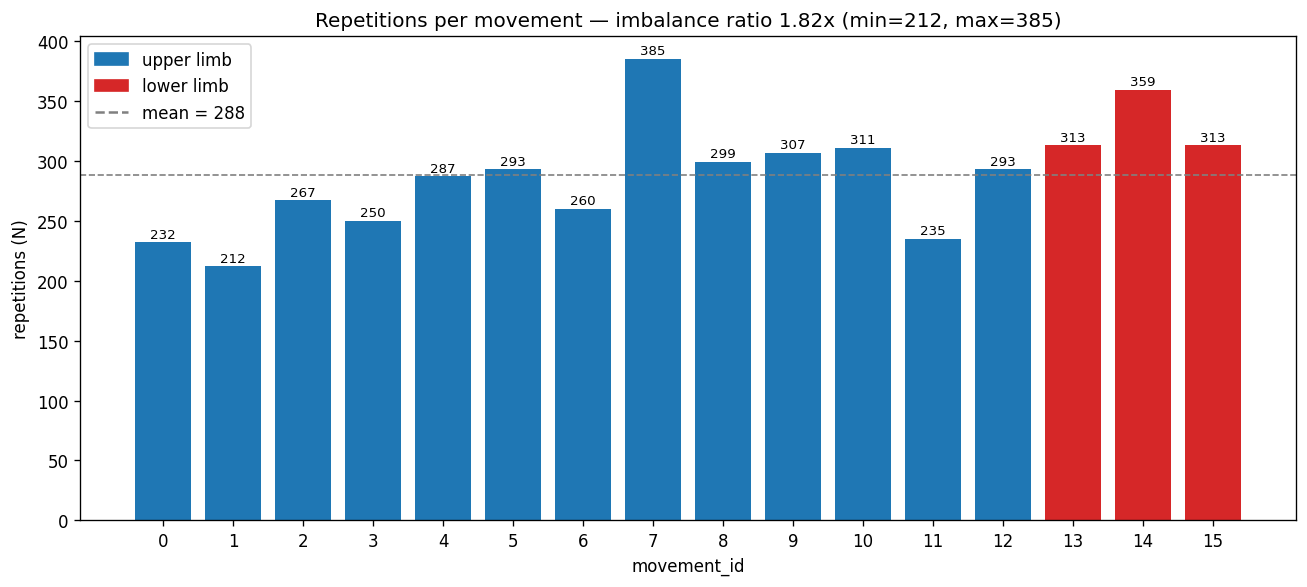

In [2]:
counts = []
for m in range(16):
    a = np.load(os.path.join(PROCESSED_DIR, f"{m:03d}_2.npy"), allow_pickle=True)
    counts.append(a.shape[0])
counts = np.array(counts)

fig, ax = plt.subplots(figsize=(11, 5))
colors = [UPPER_COLOR if LIMB[m] == "upper" else LOWER_COLOR for m in range(16)]
ax.bar(range(16), counts, color=colors)
ax.axhline(counts.mean(), color="gray", linestyle="--", linewidth=1, label=f"mean = {counts.mean():.0f}")
for m, c in enumerate(counts):
    ax.text(m, c + 4, str(c), ha="center", fontsize=8)
ax.set_xticks(range(16))
ax.set_xticklabels([f"{m}" for m in range(16)])
ax.set_xlabel("movement_id")
ax.set_ylabel("repetitions (N)")
ax.set_title(f"Repetitions per movement — imbalance ratio {counts.max()/counts.min():.2f}x (min={counts.min()}, max={counts.max()})")
handles = [plt.Rectangle((0,0),1,1,color=UPPER_COLOR), plt.Rectangle((0,0),1,1,color=LOWER_COLOR),
           plt.Line2D([0],[0], color="gray", linestyle="--")]
ax.legend(handles, ["upper limb", "lower limb", f"mean = {counts.mean():.0f}"])
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "01_class_balance.png"))
plt.show()

## Figure 2 — Per-movement distribution shape (boxplot)

Supports EDA.md Step 2.1 (univariate analysis): visualizes the spread/skew
summarized numerically in Table 1, channel `f1` (thumb flexion).

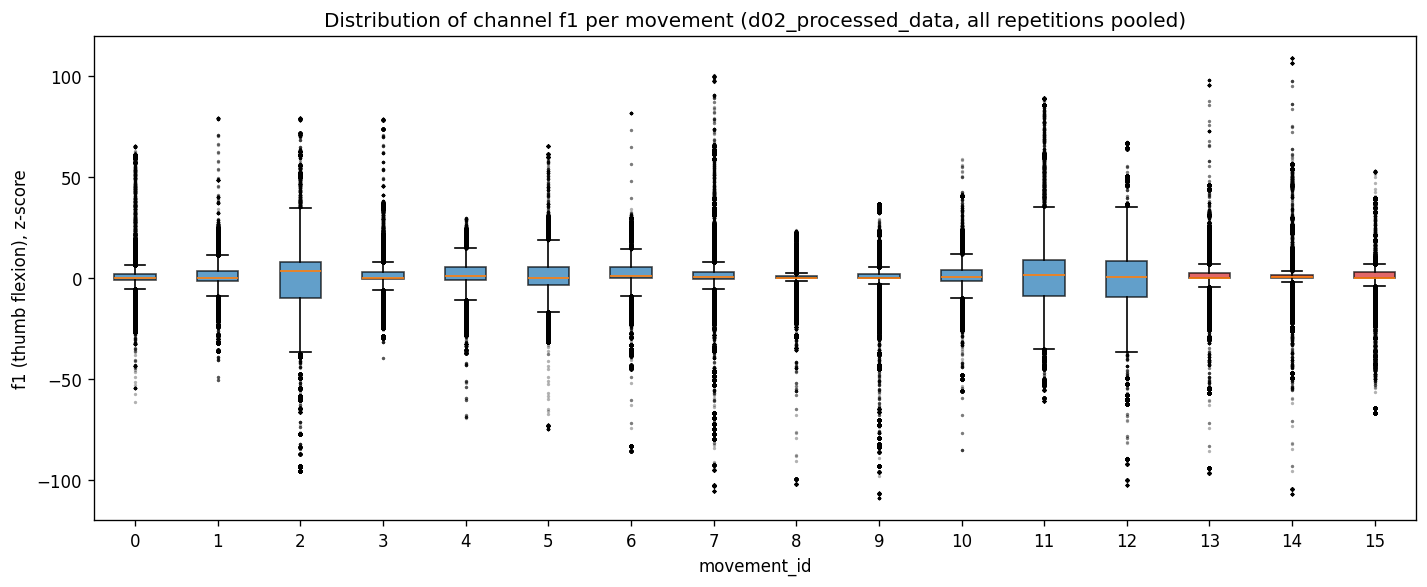

In [3]:
channel_data = []
for m in range(16):
    a = np.load(os.path.join(PROCESSED_DIR, f"{m:03d}_2.npy"), allow_pickle=True)
    channel_data.append(a[:, :, 0].ravel())

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(channel_data, patch_artist=True, showfliers=True, flierprops=dict(marker=".", markersize=2, alpha=0.3))
for patch, m in zip(bp["boxes"], range(16)):
    patch.set_facecolor(UPPER_COLOR if LIMB[m] == "upper" else LOWER_COLOR)
    patch.set_alpha(0.7)
ax.set_xticklabels(range(16))
ax.set_xlabel("movement_id")
ax.set_ylabel("f1 (thumb flexion), z-score")
ax.set_title("Distribution of channel f1 per movement (d02_processed_data, all repetitions pooled)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_boxplot_by_movement.png"))
plt.show()

## Figure 3 — Skewness, kurtosis, and IQR-outlier rate per movement

Supports EDA.md Step 2.1's discussion of distribution shape and the IQR-outlier
caveat (Table 1's Skew / Kurtosis / %IQR outliers columns, as a single visual).

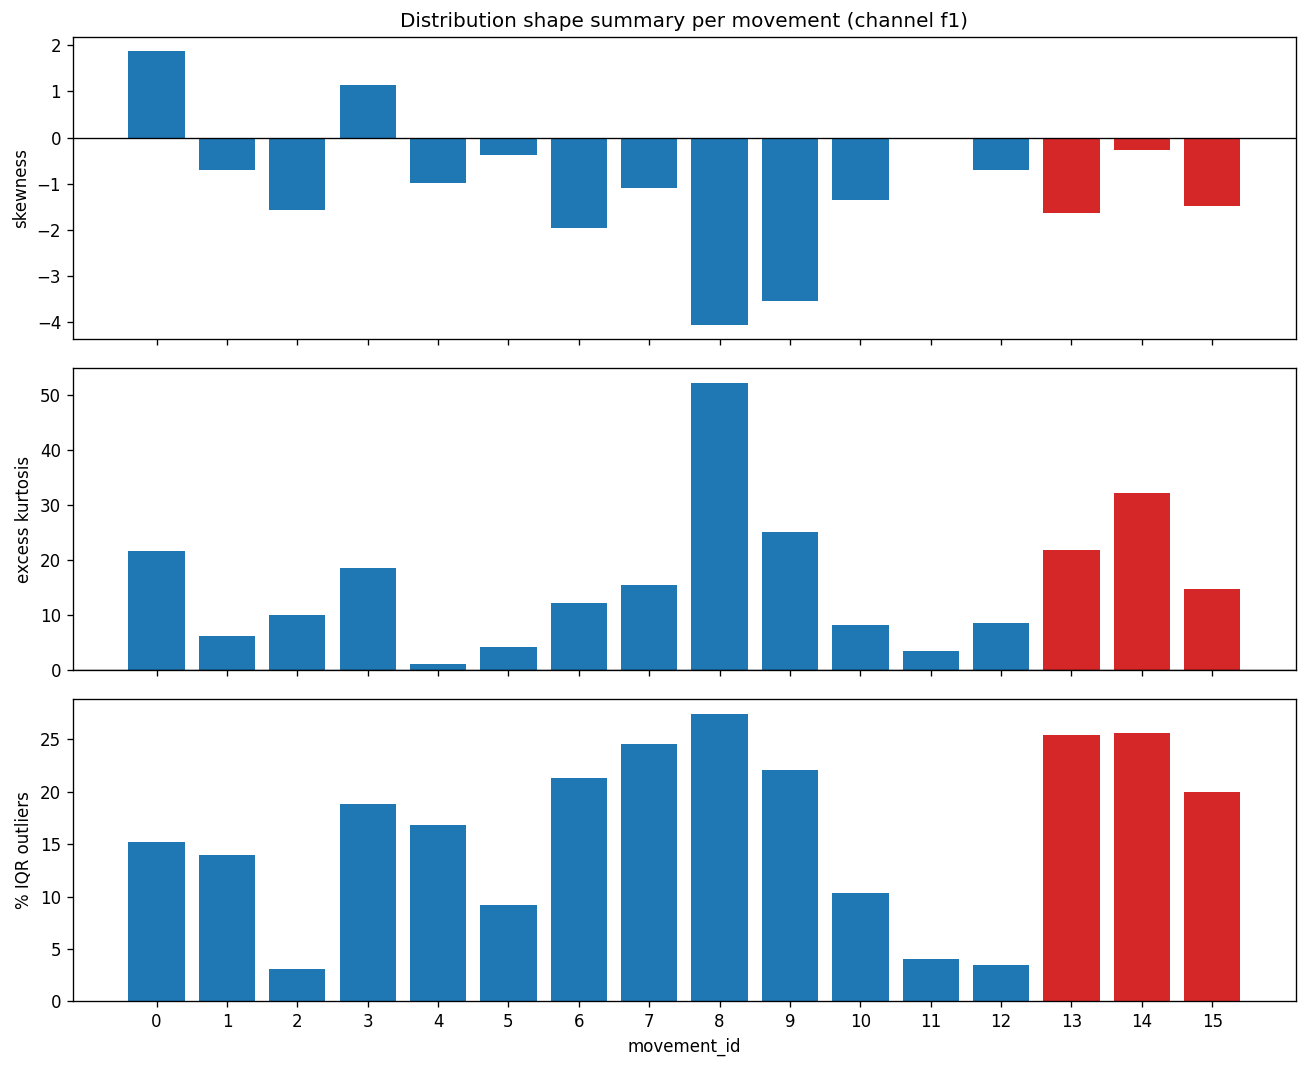

In [4]:
rows = []
for m in range(16):
    a = np.load(os.path.join(PROCESSED_DIR, f"{m:03d}_2.npy"), allow_pickle=True)
    ch0 = a[:, :, 0].ravel()
    q1, q3 = np.percentile(ch0, [25, 75])
    iqr = q3 - q1
    pct_out = ((ch0 < q1 - 1.5*iqr) | (ch0 > q3 + 1.5*iqr)).mean() * 100
    rows.append((m, stats.skew(ch0), stats.kurtosis(ch0), pct_out))
stat_df = pd.DataFrame(rows, columns=["movement_id", "skew", "kurtosis", "pct_outliers"])

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
colors = [UPPER_COLOR if LIMB[m] == "upper" else LOWER_COLOR for m in range(16)]

axes[0].bar(stat_df["movement_id"], stat_df["skew"], color=colors)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("skewness")
axes[0].set_title("Distribution shape summary per movement (channel f1)")

axes[1].bar(stat_df["movement_id"], stat_df["kurtosis"], color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("excess kurtosis")

axes[2].bar(stat_df["movement_id"], stat_df["pct_outliers"], color=colors)
axes[2].set_ylabel("% IQR outliers")
axes[2].set_xlabel("movement_id")
axes[2].set_xticks(range(16))

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_skew_kurtosis_outliers.png"))
plt.show()

## Figure 4 — Distribution overlap between two movements (with KS test)

Supports EDA.md Step 2.2 (multivariate — interaction analysis), extending
`Activity1.ipynb` Question 11 with the KS statistic used in the report text.

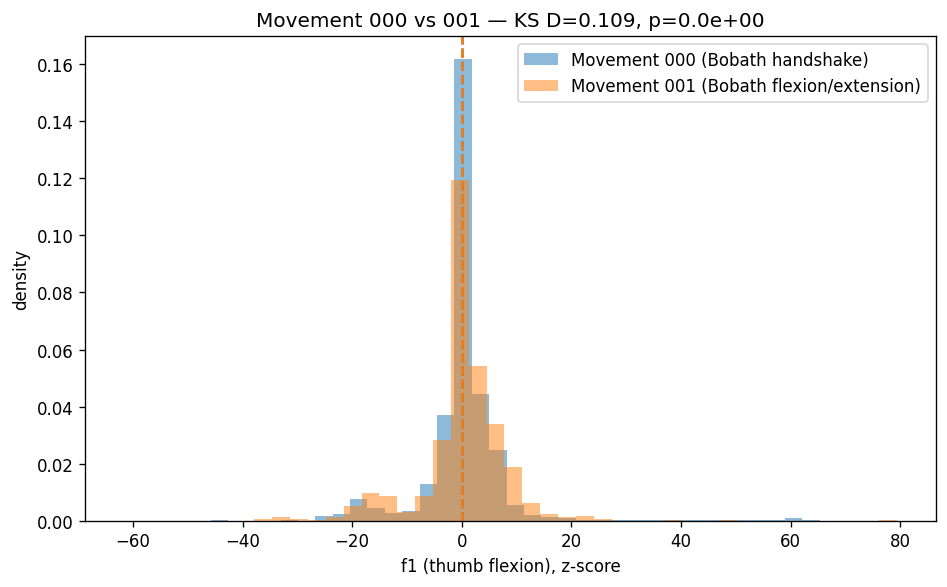

In [5]:
mov_a, mov_b = "000", "001"
da = np.load(os.path.join(PROCESSED_DIR, f"{mov_a}_2.npy"), allow_pickle=True)[:, :, 0].ravel()
db = np.load(os.path.join(PROCESSED_DIR, f"{mov_b}_2.npy"), allow_pickle=True)[:, :, 0].ravel()
ks_stat, ks_p = stats.ks_2samp(da, db)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(da, bins=40, alpha=0.5, label=f"Movement {mov_a} ({MOVEMENT_NAMES[0]})", density=True, color=UPPER_COLOR)
ax.hist(db, bins=40, alpha=0.5, label=f"Movement {mov_b} ({MOVEMENT_NAMES[1]})", density=True, color="#ff7f0e")
ax.axvline(da.mean(), color=UPPER_COLOR, linestyle="--", linewidth=1.5)
ax.axvline(db.mean(), color="#ff7f0e", linestyle="--", linewidth=1.5)
ax.set_xlabel("f1 (thumb flexion), z-score")
ax.set_ylabel("density")
ax.set_title(f"Movement {mov_a} vs {mov_b} — KS D={ks_stat:.3f}, p={ks_p:.1e}")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_histogram_overlap.png"))
plt.show()

## Figures 5 & 6 — Correlation heatmaps (Spearman)

Supports EDA.md Step 2.2's correlation tables — same numbers, as heatmaps.

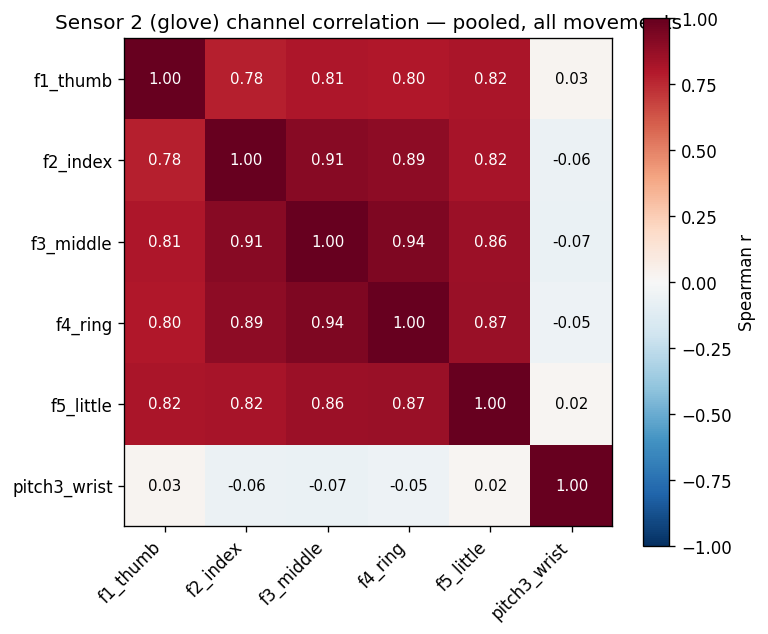

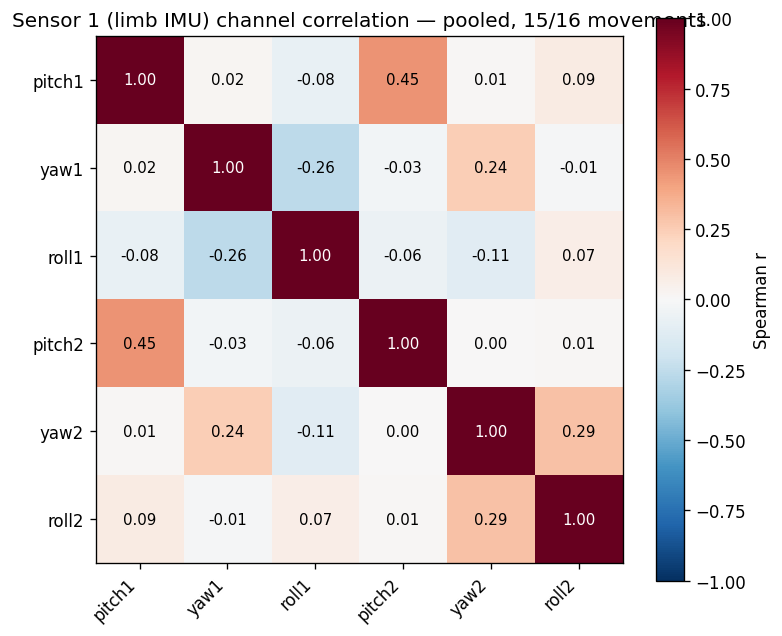

In [6]:
def plot_corr_heatmap(corr, labels, title, filename):
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center",
                     color="white" if abs(corr[i, j]) > 0.5 else "black", fontsize=9)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="Spearman r")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, filename))
    plt.show()

# Sensor 2 (glove): pooled across all 16 movements
all_ch2 = np.concatenate([np.load(os.path.join(PROCESSED_DIR, f"{m:03d}_2.npy"), allow_pickle=True).reshape(-1, 6) for m in range(16)], axis=0)
corr2, _ = stats.spearmanr(all_ch2)
plot_corr_heatmap(corr2, CHANNELS_SENSOR2, "Sensor 2 (glove) channel correlation — pooled, all movements", "05_correlation_sensor2.png")

# Sensor 1 (limb IMU): pooled across the 15 uncorrupted movements (014 skipped)
chunks = []
for m in range(16):
    try:
        a = np.load(os.path.join(PROCESSED_DIR, f"{m:03d}_1.npy"), allow_pickle=True)
        chunks.append(a.reshape(-1, 6))
    except Exception:
        pass  # movement 014: known corrupted file, see EDA.md Step 3 issue #1
all_ch1 = np.concatenate(chunks, axis=0)
corr1, _ = stats.spearmanr(all_ch1)
plot_corr_heatmap(corr1, CHANNELS_SENSOR1, "Sensor 1 (limb IMU) channel correlation — pooled, 15/16 movements", "06_correlation_sensor1.png")

## Figure 7 — Padding survives normalization as a fake constant (new finding)

Supports EDA.md Step 3 issue #6. Uses `d01_raw_data` (to locate the real
signal length) and `d02_processed_data` (to show what normalization did to
the padded tail) for the **same** sample: movement `002`, sample `144`.

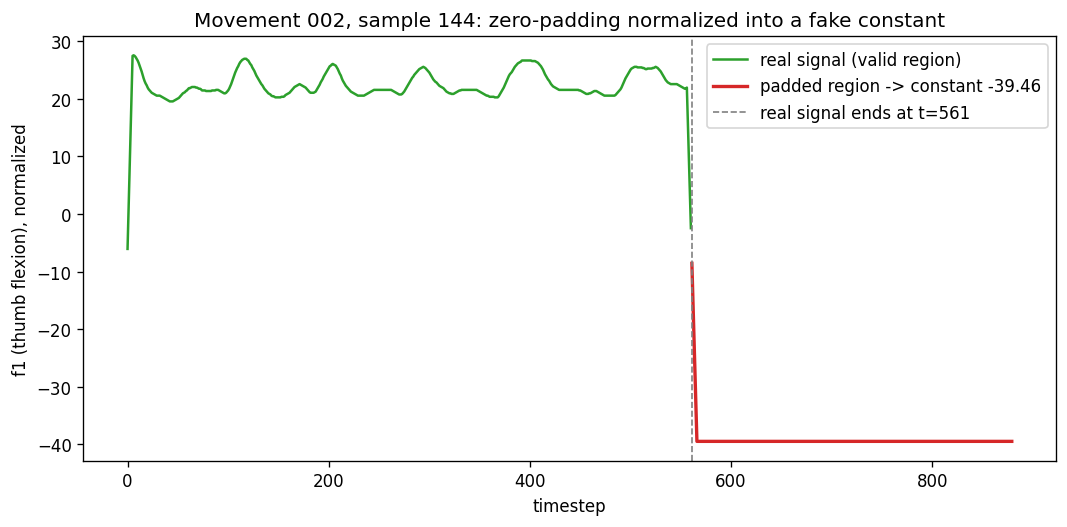

Real signal: t=0..560 (561 timesteps). Padded region: t=561..879 (319 timesteps), all equal to -39.4561.


In [7]:
def trailing_zero_length(a):
    # Vectorized count of the contiguous all-zero run at the end of each sample.
    zero_row = np.all(a == 0.0, axis=2)
    running = np.cumprod(zero_row[:, ::-1].astype(np.int8), axis=1)
    return running.sum(axis=1)

raw = np.load(os.path.join(RAW_DIR, "002_2.npy"), allow_pickle=True)
proc = np.load(os.path.join(PROCESSED_DIR, "002_2.npy"), allow_pickle=True)
trail = trailing_zero_length(raw)

sample_i = 144
vlen = raw.shape[1] - trail[sample_i]
tail_value = proc[sample_i, -1, 0]

fig, ax = plt.subplots(figsize=(9, 4.5))
t = np.arange(880)
ax.plot(t[:vlen], proc[sample_i, :vlen, 0], color="#2ca02c", label="real signal (valid region)")
ax.plot(t[vlen:], proc[sample_i, vlen:, 0], color="#d62728", linewidth=2, label=f"padded region -> constant {tail_value:.2f}")
ax.axvline(vlen, color="gray", linestyle="--", linewidth=1, label=f"real signal ends at t={vlen}")
ax.set_xlabel("timestep")
ax.set_ylabel("f1 (thumb flexion), normalized")
ax.set_title(f"Movement 002, sample {sample_i}: zero-padding normalized into a fake constant")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "07_padding_artifact.png"))
plt.show()

print(f"Real signal: t=0..{vlen-1} ({vlen} timesteps). Padded region: t={vlen}..879 ({880-vlen} timesteps), all equal to {tail_value:.4f}.")

## Figure 8 — Physically impossible angle value, with frozen/dropout pattern

Supports EDA.md Step 3 issue #4. Shown on **raw** data (`d01_raw_data`), before
any repair, to illustrate the defect as it actually appears in the source
files: movement `4`, sample `124`, channel `yaw2` (sensorID=1).

The value goes outside the mathematically valid ±180° range (certain,
regardless of cause), then gets stuck at two different bit-identical values
for many consecutive samples each — consistent with a wireless dropout
holding the last received reading, not a claim about a specific instantaneous
angular velocity (we don't know how much real time passed while frozen).

Frozen (bit-identical) runs of 3+ samples: 10 total, 3 of them also outside +-180 deg:
  t=0..62 (63 samples, 1260ms) frozen at 30.52 deg  (in-range, likely genuine stillness)
  t=65..70 (6 samples, 120ms) frozen at -25.96 deg  (in-range, likely genuine stillness)
  t=87..94 (8 samples, 160ms) frozen at -116.14 deg  (in-range, likely genuine stillness)
  t=134..136 (3 samples, 60ms) frozen at -225.03 deg  <-- also outside +-180 deg (invalid)
  t=137..181 (45 samples, 900ms) frozen at -36.46 deg  (in-range, likely genuine stillness)
  t=290..295 (6 samples, 120ms) frozen at -98.02 deg  (in-range, likely genuine stillness)
  t=296..298 (3 samples, 60ms) frozen at -11.77 deg  (in-range, likely genuine stillness)
  t=385..396 (12 samples, 240ms) frozen at 884.44 deg  <-- also outside +-180 deg (invalid)
  t=478..480 (3 samples, 60ms) frozen at 18.93 deg  (in-range, likely genuine stillness)
  t=604..606 (3 samples, 60ms) frozen at 381.83 deg  <-- also outside +-180 deg (invalid)


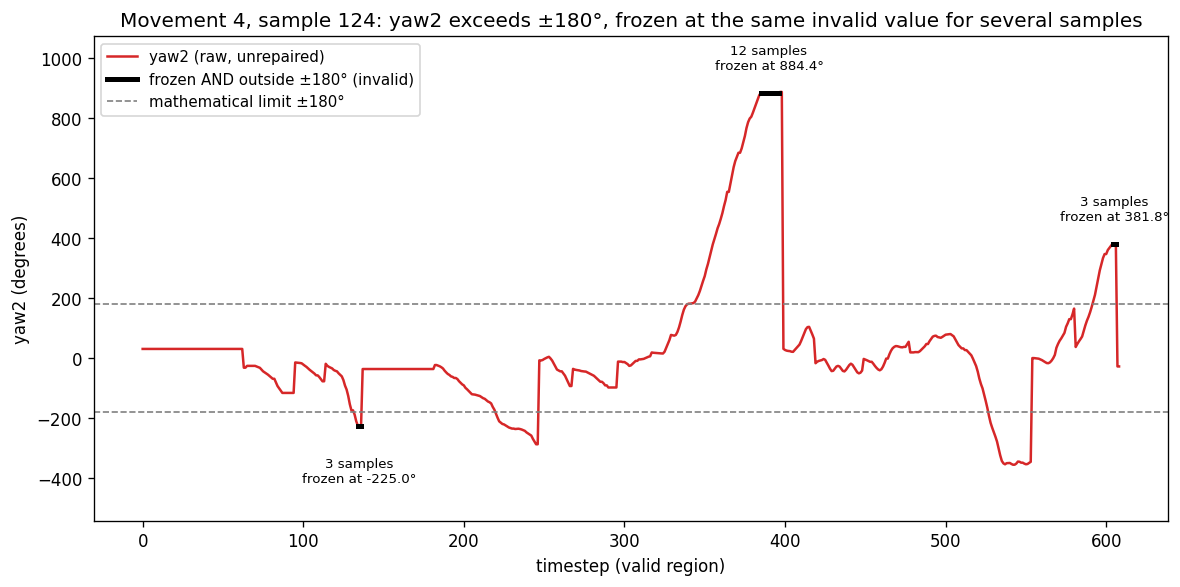

In [8]:
def find_frozen_runs(x, min_len=3):
    # Find runs of 3+ consecutive bit-identical values (stale-value hold signature).
    runs = []
    i = 0
    while i < len(x):
        j = i
        while j + 1 < len(x) and x[j+1] == x[i]:
            j += 1
        if j - i + 1 >= min_len:
            runs.append((i, j, x[i]))
        i = j + 1
    return runs

a4_1 = np.load(os.path.join(RAW_DIR, "004_1.npy"), allow_pickle=True)
trail4_1 = trailing_zero_length(a4_1)
sample_i = 124
vlen = a4_1.shape[1] - trail4_1[sample_i]
yaw2_idx = CHANNELS_SENSOR1.index("yaw2")
x = a4_1[sample_i, :vlen, yaw2_idx]

frozen_runs = find_frozen_runs(x)
# Only frozen runs that ALSO violate the mathematical ±180 bound are evidence of a
# fault -- a value frozen at, say, 30 deg for a while is most likely the sensor
# legitimately holding still before the exercise starts, not a defect. We only flag
# the ones that are both frozen AND out-of-bounds.
invalid_frozen = [r for r in frozen_runs if abs(r[2]) > 180]
print(f"Frozen (bit-identical) runs of 3+ samples: {len(frozen_runs)} total, {len(invalid_frozen)} of them also outside +-180 deg:")
for start, end, val in frozen_runs:
    flag = "  <-- also outside +-180 deg (invalid)" if abs(val) > 180 else "  (in-range, likely genuine stillness)"
    print(f"  t={start}..{end} ({end-start+1} samples, {(end-start+1)*20}ms) frozen at {val:.2f} deg{flag}")

fig, ax = plt.subplots(figsize=(10, 5))
t = np.arange(vlen)
ax.plot(t, x, color="#d62728", label="yaw2 (raw, unrepaired)", zorder=2)
for k, (start, end, val) in enumerate(invalid_frozen):
    ax.plot(t[start:end+1], x[start:end+1], color="black", linewidth=3, zorder=3,
            label="frozen AND outside ±180° (invalid)" if k == 0 else None)
    ax.annotate(f"{end-start+1} samples\nfrozen at {val:.1f}°", xy=(t[(start+end)//2], val),
                xytext=(0, 14 if val > 0 else -34), textcoords="offset points",
                ha="center", fontsize=8)
ax.axhline(180, color="gray", linestyle="--", linewidth=1, label="mathematical limit ±180°")
ax.axhline(-180, color="gray", linestyle="--", linewidth=1)
ymin, ymax = x.min(), x.max()
pad = 0.15 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)
ax.set_xlabel("timestep (valid region)")
ax.set_ylabel("yaw2 (degrees)")
ax.set_title(f"Movement 4, sample {sample_i}: yaw2 exceeds ±180°, frozen at the same invalid value for several samples")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "08_invalid_angle_example.png"))
plt.show()

In [9]:
print("Figures saved:")
for f in sorted(os.listdir(FIG_DIR)):
    print(" -", os.path.join(FIG_DIR, f))

Figures saved:
 - /Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/EDA_Report/figures/01_class_balance.png
 - /Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/EDA_Report/figures/02_boxplot_by_movement.png
 - /Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/EDA_Report/figures/03_skew_kurtosis_outliers.png
 - /Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/EDA_Report/figures/04_histogram_overlap.png
 - /Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/EDA_Report/figures/05_correlation_sensor2.png
 - /Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/EDA_Report/figures/06_correlation_sensor1.png
 - /Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/EDA_Report/figures/07